"Rancangan Sistem Klasifikasi AI untuk Memprediksi Status Jejak Karbon Individu Berdasarkan Pola Konsumsi Harian"

In [1]:
import pandas as pd

Upload Dataset:

In [2]:
df = pd.read_csv ('Carbon Emission.csv')

Cleaning dan Preprocessing:

In [3]:
# melihat jumlah nilai null padaa dataset
df.isnull().sum()

Body Type                           0
Sex                                 0
Diet                                0
How Often Shower                    0
Heating Energy Source               0
Transport                           0
Vehicle Type                     6721
Social Activity                     0
Monthly Grocery Bill                0
Frequency of Traveling by Air       0
Vehicle Monthly Distance Km         0
Waste Bag Size                      0
Waste Bag Weekly Count              0
How Long TV PC Daily Hour           0
How Many New Clothes Monthly        0
How Long Internet Daily Hour        0
Energy efficiency                   0
Recycling                           0
Cooking_With                        0
CarbonEmission                      0
dtype: int64

In [4]:
# melihat jumlah data yang duplikat pada dataset
df.duplicated().sum()

np.int64(0)

In [5]:
# mengubah seluruh nilai null pada kolom 'Vehicle Type' menjadi 'Unknown'
df['Vehicle Type'] = df['Vehicle Type'].fillna('Unknown') 

In [6]:
# mengubah seluruh format data ke numerical
df['CarbonEmission'] = pd.to_numeric (df['CarbonEmission'], errors= 'coerce')

In [7]:
df = df.dropna() # pembersihan ulang (just in case)

In [8]:
# menghitung median sebagai acuan nilai tengah untuk mengidentifikasi status emisi, rendah emisi (0) dan tinggi emisi (1)
median_emisi = df['CarbonEmission'].median()

In [9]:
# menentukan status emisi
def tentukan_status(nilai_emisi):
    if nilai_emisi > median_emisi:
        return 1
    else:
        return 0

df['Status_Emisi'] = df['CarbonEmission'].apply(tentukan_status)

In [10]:
# mengubah data teks biasa menjadi numerical pada kolom 'How Often Shower'
df['How Often Shower'] = df['How Often Shower'].astype('category')
kategori_shower = df['How Often Shower'].cat.categories.tolist()
df['How Often Shower'] = df['How Often Shower'].cat.codes

Exploratory Data Analysis (EDA):

In [11]:
df.describe()

,How Often Shower,Monthly Grocery Bill,Vehicle Monthly Distance Km,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,CarbonEmission,Status_Emisi
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.493700,173.875200,2031.485900,4.024600,12.139200,25.109000,11.889100,2269.147300,0.499600
std,1.123604,72.234018,2769.715597,1.990375,7.106369,14.698725,7.277218,1017.675247,0.500025
min,0.000000,50.000000,0.000000,1.000000,0.000000,0.000000,0.000000,306.000000,0.000000
25%,0.000000,111.000000,69.000000,2.000000,6.000000,13.000000,6.000000,1538.000000,0.000000
50%,1.000000,173.000000,823.000000,4.000000,12.000000,25.000000,12.000000,2080.000000,0.000000
75%,3.000000,237.000000,2516.750000,6.000000,18.000000,38.000000,18.000000,2768.000000,1.000000
max,3.000000,299.000000,9999.000000,7.000000,24.000000,50.000000,24.000000,8377.000000,1.000000


In [12]:
df['Status_Emisi'].value_counts()

Status_Emisi
0    5004
1    4996
Name: count, dtype: int64

In [13]:
kolom_eda = ['Vehicle Monthly Distance Km', 'How Many New Clothes Monthly', 'How Long Internet Daily Hour', 'CarbonEmission']
df[kolom_eda].corr()

,Vehicle Monthly Distance Km,How Many New Clothes Monthly,How Long Internet Daily Hour,CarbonEmission
Vehicle Monthly Distance Km,1.000000,0.004934,-0.003497,0.594171
How Many New Clothes Monthly,0.004934,1.000000,0.006426,0.198887
How Long Internet Daily Hour,-0.003497,0.006426,1.000000,0.043878
CarbonEmission,0.594171,0.198887,0.043878,1.000000


C:\Users\My ASUS\AppData\Local\Temp\ipykernel_14360\3037803485.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Status_Emisi', data=df, palette='Set2')


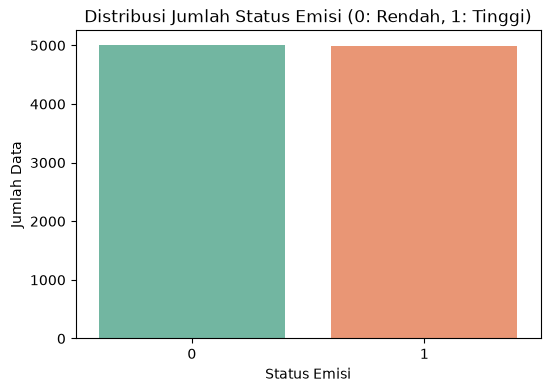

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat grafik diagram batang
plt.figure(figsize=(6,4))
sns.countplot(x='Status_Emisi', data=df, palette='Set2')
plt.title('Distribusi Jumlah Status Emisi (0: Rendah, 1: Tinggi)')
plt.xlabel('Status Emisi')
plt.ylabel('Jumlah Data')
plt.show()

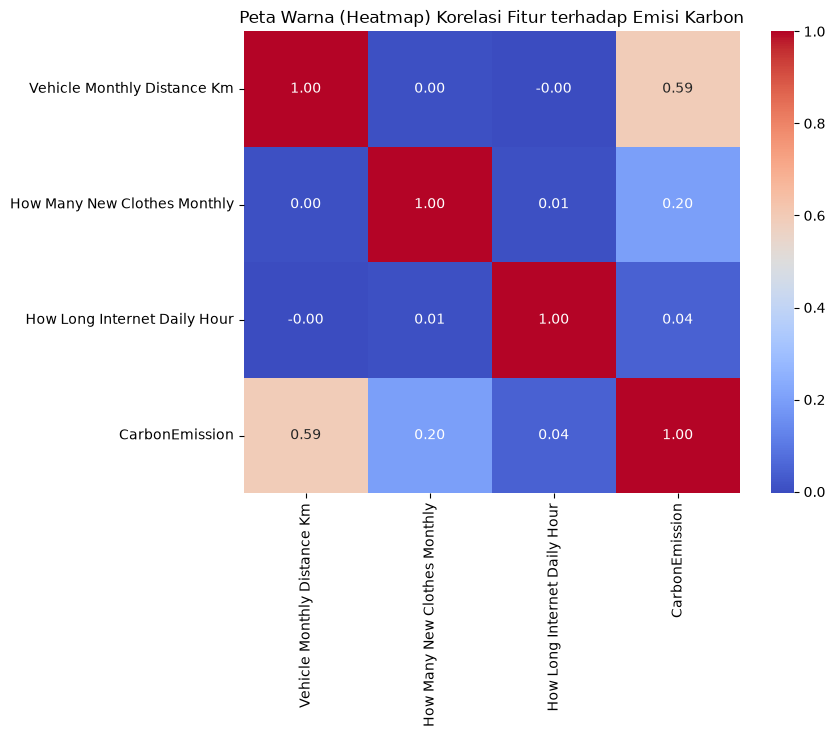

In [15]:
# Membuat grafik peta warna korelasi
plt.figure(figsize=(8,6))
sns.heatmap(df[kolom_eda].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Peta Warna (Heatmap) Korelasi Fitur terhadap Emisi Karbon')
plt.show()

FEATURE SELECTION:

In [16]:
# Menentukan Fitur (X) dan Target (Y) untuk model AI
X = df[['How Often Shower', 'Vehicle Monthly Distance Km', 'How Many New Clothes Monthly', 'How Long Internet Daily Hour']] #fitur input
Y = df['Status_Emisi'] #target tebakan

TRAIN - Test Split:

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

PEMODELAN

In [19]:
#Algoritma 1: Decision Tree Classifier 
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(max_depth=3, random_state=1)
model_dt.fit(X_train, Y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in 

In [20]:
#Algoritma 2: Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=1)
model_rf.fit(X_train, Y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: 

EVALUASI MODEL - membandingkan akurasi

In [21]:
from sklearn.metrics import accuracy_score, classification_report

#menyuruh kedua model menebah data testing
prediksi_dt = model_dt.predict(X_test)
prediksi_rf = model_rf.predict(X_test)

#menghitung persentase kebenaran tebakan
akurasi_dt = accuracy_score(Y_test, prediksi_dt)
akurasi_rf = accuracy_score(Y_test, prediksi_rf)

In [22]:
print("="*50)
print(f" AKURASI ALGORITMA 1 (Decision Tree) : {akurasi_dt * 100:.2f}%")
print(f" AKURASI ALGORITMA 2 (Random Forest) : {akurasi_rf * 100:.2f}%")
print("="*50)

#menampilkan detail laporan performa
print("\n[INFO] Laporan Detail Klasifikasi Decision Tree:")
print(classification_report(Y_test, prediksi_dt))

print("\n[INFO] Laporan Detail Klasifikasi Random Forest:")
print(classification_report(Y_test, prediksi_rf))

 AKURASI ALGORITMA 1 (Decision Tree) : 67.85%
 AKURASI ALGORITMA 2 (Random Forest) : 67.80%

[INFO] Laporan Detail Klasifikasi Decision Tree:
              precision    recall  f1-score   support

           0       0.65      0.77      0.70       990
           1       0.73      0.59      0.65      1010

    accuracy                           0.68      2000
   macro avg       0.69      0.68      0.68      2000
weighted avg       0.69      0.68      0.68      2000


[INFO] Laporan Detail Klasifikasi Random Forest:
              precision    recall  f1-score   support

           0       0.64      0.80      0.71       990
           1       0.74      0.56      0.64      1010

    accuracy                           0.68      2000
   macro avg       0.69      0.68      0.67      2000
weighted avg       0.69      0.68      0.67      2000



PREDIKSI & INTERPRETASI

In [23]:
print("\n" + "="*55)
print("   SISTEM AI PREDIKSI STATUS JEJAK KARBON INDIVIDU   ")
print("="*55)
print("Silakan lihat daftar pilihan opsi mandi kamu:")
for i, opsi in enumerate(kategori_shower):
    print(f" [{i}] {opsi}")

try:
    # --- INPUT DATA USER ---
    input_shower = int(input(f"\nMasukkan nomor opsi mandi (0 sampai {len(kategori_shower)-1}): "))
    
    if input_shower < 0 or input_shower >= len(kategori_shower):
        print(f"\n[Error] Opsi mandi tidak valid! Pilih angka 0 sampai {len(kategori_shower)-1}.\n")
    else:
        input_jarak = float(input("Masukkan jarak tempuh kendaraan per bulan (km): "))
        input_baju = int(input("Masukkan jumlah baju baru yang dibeli per bulan (pcs): "))
        input_internet = float(input("Masukkan durasi internetan per hari (jam): "))

        # Menyusun data input menjadi format tabel dataframe sesuai urutan fitur X
        data_user = pd.DataFrame([[input_shower, input_jarak, input_baju, input_internet]], columns=X.columns)

        # AI MELAKUKAN PREDIKSI BERBASIS MODEL DECISION TREE TERBAIK KELOMPOK
        hasil_prediksi = model_dt.predict(data_user)

        # --- TAHAP 8 & 9: HASIL PREDIKSI, INTERPRETASI & TINGKAT AKURASI ---
        print("\n" + "="*55)
        print("HASIL PREDIKSI & INTERPRETASI AI KELOMPOK:")
        print("="*55)
        
        if hasil_prediksi == 1:
            print(" >> STATUS EMISI ANDA: TINGGI (Berbahaya bagi Lingkungan) <<")
            # Memanggil akurasi_dt hasil evaluasi Decision Tree sebelumnya
            print(f" [Tingkat Kepercayaan/Akurasi Prediksi: {akurasi_dt * 100:.2f}%]") 
            
            print("\n[Interpretasi Data]:")
            print(f" Gaya hidup Anda menghasilkan emisi di atas batas median nilai tengah.")
            print(f" Faktor kontribusi terbesar didorong oleh mobilitas kendaraan pribadi ({input_jarak} km/bulan)")
            print(f" serta konsumsi pakaian baru sebanyak ({input_baju} pcs/bulan).")
            print("\n[Tahap 9: Rekomendasi Solusi]:")
            print(" 1. Kurangi penggunaan kendaraan pribadi, beralihlah ke angkutan umum/sepeda.")
            print(" 2. Batasi pembelian baju baru (hindari tren fast fashion yang boros energi).")
        else:
            print(" >> STATUS EMISI ANDA: RENDAH (Bagus dan Ramah Lingkungan) <<")
            # Memanggil akurasi_dt hasil evaluasi Decision Tree sebelumnya
            print(f" [Tingkat Kepercayaan/Akurasi Prediksi: {akurasi_dt * 100:.2f}%]") 
            
            print("\n[Interpretasi Data]:")
            print(" Gaya hidup Anda terbukti hemat energi karena emisi karbon yang dihasilkan")
            print(" berada di bawah batas rata-rata median kelompok masyarakat.")
            print("\n[Tahap 9: Rekomendasi Solusi]:")
            print(" 1. Pertahankan kebiasaan bijak dalam berkendara dan belanja konsumtif.")
            print(" 2. Sebarkan gaya hidup ramah lingkungan ini ke lingkaran terdekat Anda!")
            
        print("="*55 + "\n")

except ValueError:
    print("\n[Error] Input tidak valid! Harap masukkan data dalam bentuk angka.\n")



   SISTEM AI PREDIKSI STATUS JEJAK KARBON INDIVIDU   
Silakan lihat daftar pilihan opsi mandi kamu:
 [0] daily
 [1] less frequently
 [2] more frequently
 [3] twice a day

HASIL PREDIKSI & INTERPRETASI AI KELOMPOK:
 >> STATUS EMISI ANDA: TINGGI (Berbahaya bagi Lingkungan) <<
 [Tingkat Kepercayaan/Akurasi Prediksi: 67.85%]

[Interpretasi Data]:
 Gaya hidup Anda menghasilkan emisi di atas batas median nilai tengah.
 Faktor kontribusi terbesar didorong oleh mobilitas kendaraan pribadi (5000.0 km/bulan)
 serta konsumsi pakaian baru sebanyak (30 pcs/bulan).

[Tahap 9: Rekomendasi Solusi]:
 1. Kurangi penggunaan kendaraan pribadi, beralihlah ke angkutan umum/sepeda.
 2. Batasi pembelian baju baru (hindari tren fast fashion yang boros energi).

